# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


 -----------------------
|   Imported CIBUSmod   |
 -----------------------
commit : 6a426bc864c936c1067560c0d477019594a71a5b
branch : main
dirty  : True
remote : https://github.com/SLU-foodsystems/CIBUSmod
    


Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

def annotate_axs(axs, size=10, offset=(-3,1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.annotate(
            f'({string.ascii_lowercase[i % 26]})',
            xy = (0,1), xycoords = 'axes fraction',
            xytext = offset, textcoords = 'offset fontsize',
            fontsize=size, fontweight='bold', va='bottom', ha='right'
        )

def cat7_cmap():
    from matplotlib.colors import ListedColormap
    colors = [
        "#2c7fb8",
        "#f03b20",
        "#31a354",
        "#a1dab4",
        "#fecc5c",
        "#ffffcc",
        "#ffffff",
    ]
    cmap_name = "cat7"
    cmap = ListedColormap(colors, name=cmap_name)
    return cmap

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [5]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('2026-04-17')]
runs

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [6]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')

session.cache.clear()

Base20, 2030 finished successfully in 7min 19s
Base20, 2040 finished successfully in 7min 37s
Base20, 2025 finished successfully in 7min 41s
Base20, 2020 finished successfully in 8min 10s
Base20, 2045 finished successfully in 8min 20s
Base20, 2035 finished successfully in 8min 36s
Base20, 2050 finished successfully in 8min 37s
Sust50, 2020 finished successfully in 8min 38s
Sust50, 2025 finished successfully in 4min 29s
Sust50, 2030 finished successfully in 5min 37s
Sust50, 2035 finished successfully in 5min 41s
Sust50, 2040 finished successfully in 6min 3s
Sust50, 2045 finished successfully in 6min 1s
Sust50, 2050 finished successfully in 5min 44s
CPU times: total: 125 ms
Wall time: 14min 27s


## Plot output

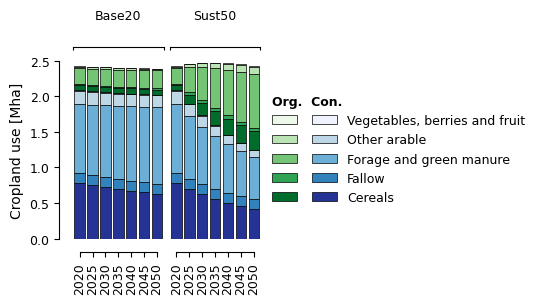

Share of cropland:


prod_system  conventional    organic  total
scn    year                                
Base20 2020     86.120670  13.879330  100.0
       2025     85.828082  14.171918  100.0
       2030     85.567199  14.432801  100.0
       2035     85.333804  14.666196  100.0
       2040     85.108630  14.891370  100.0
       2045     84.894968  15.105032  100.0
       2050     84.700034  15.299966  100.0
Sust50 2020     86.097915  13.902085  100.0
       2025     77.249431  22.750569  100.0
       2030     70.251577  29.748423  100.0
       2035     64.375800  35.624200  100.0
       2040     59.395778  40.604222  100.0
       2045     55.138578  44.861422  100.0
       2050     51.430906  48.569094  100.0

Total cropland area:


prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.083010  0.335701  2.418711
       2025      2.071183  0.341993  2.413176
       2030      2.058842  0.347269  2.406111
       2035      2.046357  0.351704  2.398061
       2040      2.037095  0.356428  2.393524
       2045      2.030168  0.361220  2.391388
       2050      2.022399  0.365320  2.387719
Sust50 2020      2.082504  0.336258  2.418763
       2025      1.897145  0.558724  2.455869
       2030      1.734041  0.734289  2.468330
       2035      1.588315  0.878940  2.467254
       2040      1.461013  0.998780  2.459793
       2045      1.349214  1.097737  2.446951
       2050      1.247593  1.178172  2.425765

Share "Forage and green manure":


prod_system  conventional    organic
scn    year                         
Base20 2020     46.704312  66.265842
       2025     47.964138  66.952772
       2030     49.138141  67.575261
       2035     50.247686  68.142175
       2040     51.306333  68.686119
       2045     52.322325  69.207431
       2050     53.279130  69.692741
Sust50 2020     46.692656  66.308095
       2025     46.780999  63.458893
       2030     46.933669  63.358453
       2035     47.075716  63.567552
       2040     47.260194  63.861951
       2045     47.517967  64.167813
       2050     47.816992  64.481057

Share "Cereals":


prod_system  conventional    organic
scn    year                         
Base20 2020     37.389974  21.195061
       2025     36.172968  20.834286
       2030     35.054963  20.511084
       2035     34.008604  20.213981
       2040     33.024252  19.933887
       2045     32.097656  19.669769
       2050     31.229734  19.421355
Sust50 2020     37.398422  21.168819
       2025     36.676717  22.385269
       2030     35.942015  22.489095
       2035     35.233293  22.503185
       2040     34.532621  22.484993
       2045     33.823387  22.438140
       2050     33.123322  22.345061

In [7]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

# Hide crop group for organic to make nice legend
plot_data_ = plot_data.copy()
plot_data_.columns = \
pd.MultiIndex.from_tuples(
    [(ps,cg) if ps != 'organic' else (ps,' ') for ps,cg in plot_data_.columns],
    names = plot_data_.columns.names
)

fig, ax = plt.subplots(figsize=(5.5,3))
cm.plot.bar(
    plot_data_.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap,
    ylim=(0,2.5)
)
ax.legend(
    loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, frameon=False, reverse=True, fontsize=9,
    columnspacing = 0.1,
    title='Org.  Con.',
    title_fontproperties={'weight': 'bold', 'size': 9},  # Make title bold and adjust size
    alignment="left"  # Align legend text to the left
)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig10.png', dpi=300)
plt.savefig('figs/mp2025/Fig10.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
tab_data2 = plot_data.T.groupby('prod_system').apply(lambda x: x/x.sum()*100).T.droplevel(0, axis=1)

print('Share of cropland:')
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
print('Total cropland area:')
display(tab_data)
print('Share "Forage and green manure":')
display(tab_data2.xs('Forage and green manure', level='crop_group2', axis=1))
print('Share "Cereals":')
display(tab_data2.xs('Cereals', level='crop_group2', axis=1))

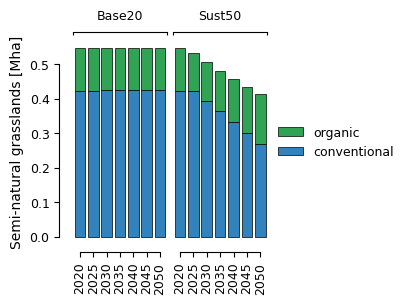

In [8]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

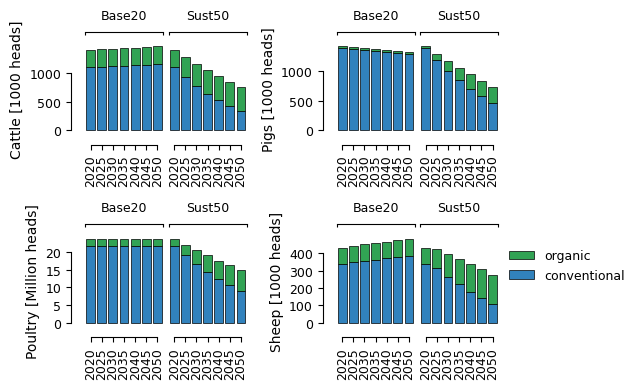

In [9]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [10]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.350227  21.233468   
Barley, spring                      conventional   5.015036   5.969594   
Barley, winter                      conventional   6.374800   7.586829   
Beans, dry                          conventional   1.771584   1.769239   
Broad beans and horse beans, dry    conventional   3.289615   4.123577   
Buckwheat                           conventional   2.840013   1.620071   
Cabbages, cauliflowers and broccoli conventional  21.727571  27.050947   
Carrots                             conventional  67.440384  85.541378   
Cereals for fodder                  conventional   3.494634   3.497637   
Cucumbers                           conventional  61.926202   6.079451   
Currants                            conventional   1.475873   1.498535   
Energy grass                        conventional   4.026604   4.027126   
Fallow                              conventional   2.333995   2.331681   
Green manure                        conventional   4.804991   4.807808   
Herbs                               conventional   3.996302   5.094274   
Lettuce and spinach                 conventional  15.539575  19.689853   
Ley for fodder                      conventional   5.506939   5.520114   
Ley for grazing                     conventional   4.473273   4.500938   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.971678   3.970202   
Maize (corn)                        conventional   6.100146   6.099150   
Maize for forage and silage         conventional  10.747797  10.727552   
Mixed cereals                       conventional   3.332628   3.300055   
Oats                                conventional   4.624457   5.750144   
Onions                              conventional  51.291484  65.027608   
Other berries                       conventional   1.686435   1.753531   
Other crops for fodder              conventional   4.331074   4.344940   
Other fruit                         conventional   4.559852   4.579973   
Other root vegetables               conventional  34.749963  43.853964   
Other vegetables                    conventional   3.193751   3.849194   
Pears                               conventional  15.669682  15.740309   
Peas, dry                           conventional   3.413771   4.265475   
Peas, green                         conventional   4.400881   4.417771   
Potatoes, starch                    conventional  45.153215  55.109297   
Potatoes, table                     conventional  38.308833  46.619457   
Pumpkins and squash                 conventional  27.248091  34.046841   
Quinoa                              conventional   1.305023   1.305022   
Rapeseed, spring                    conventional   1.837043   2.197664   
Rapeseed, winter                    conventional   3.557181   4.261834   
Rye                                 conventional   6.907851   8.623127   
Short rotation coppice              conventional   4.693633   4.692310   
Strawberries                        conventional   6.872948   6.886929   
Sugar beet                          conventional  76.583787  95.688482   
Triticale, spring                   conventional   3.306520   3.309256   
Triticale, winter                   conventional   5.759551   5.752426   
Wheat, spring                       conventional   4.629564   6.297964   
Wheat, winter                       conventional   7.248332   9.904375   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   23.834207  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.106112   8.105939   8.067802
Barley, spring                   organic       3.175090   3.266382   4.278273
Barley, winter                   organic       3.983039   4.093117   5.005225
Beans, dry                       organic       1.401542   1.695936   1.850256
Broad beans and horse beans, dry organic       2.470684   2.876805   3.406534
Buckwheat                        organic       0.907151   0.923129   0.825652
Carrots                          organic      58.611529  74.499816  80.503618
Cereals for fodder               organic       3.084632   3.081047   3.130301
Cucumbers                        organic      10.479788  13.307485  14.432602
Energy grass                     organic       3.578695   3.567811   3.689950
Fallow                           organic       2.248316   2.242975   2.317967
Green manure                     organic       4.521372   4.514614   4.933329
Herbs                            organic       0.870493   1.107286   1.202061
Lettuce and spinach              organic       5.836484   7.414979   8.037861
Ley for fodder                   organic       4.727917   4.731651   4.797494
Ley for grazing                  organic       3.822542   3.841610   3.899427
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.549728   3.546568   3.739269
Maize (corn)                     organic       3.917984   3.914008   3.883016
Mixed cereals                    organic       2.697893   2.719273   3.053749
Oats                             organic       3.042744   3.148500   3.944477
Onions                           organic      25.812114  32.787598  35.470736
Other crops for fodder           organic       3.575994   3.582971   3.602446
Other root vegetables            organic       7.240771   9.201041   9.937917
Other vegetables                 organic       1.371260        NaN   2.677966
Pears                            organic       5.464430   5.469616   5.437627
Peas, dry                        organic       2.523616   2.935946   3.572583
Potatoes, starch                 organic            NaN        NaN  40.528367
Potatoes, table                  organic      26.035663  31.938601  35.359840
Rapeseed, spring                 organic       0.709486   0.941309   1.143557
Rapeseed, winter                 organic       2.137385   2.828913   3.358424
Rye                              organic       3.871881   5.425918   5.954502
Short rotation coppice           organic       4.498591   4.482777   4.622371
Triticale, spring                organic       2.109386   2.106871   2.034047
Triticale, winter                organic       4.235067   4.226795   4.007661
Wheat, spring                    organic       2.915887   3.624190   4.281829
Wheat, winter                    organic       4.435256   5.526395   6.120163

scn     year
Base20  2020     0.771066
        2025     0.757427
        2030     0.744362
        2035     0.734141
        2040     0.723389
        2045     0.712684
        2050     0.703720
Sust50  2020     0.769606
        2025     3.158028
        2030     4.821260
        2035     6.248442
        2040     7.603928
        2045     8.958958
        2050    10.382462
Name: Green manure, dtype: float64

scn     year
Base20  2020    145.012544
        2025    143.585217
        2030    142.127732
        2035    140.643157
        2040    139.305860
        2045    138.082930
        2050    136.791892
Sust50  2020    144.995354
        2025    137.139120
        2030    129.802688
        2035    123.300741
        2040    117.692261
        2045    112.754273
        2050    108.170855
Name: value, dtype: float64

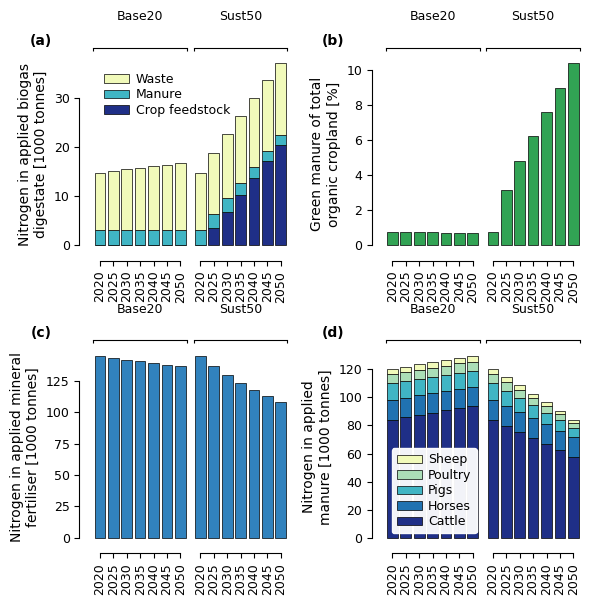

In [11]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

plt.tight_layout()
annotate_axs(axs)
plt.savefig('figs/mp2025/Fig12.png', dpi=300)
plt.savefig('figs/mp2025/Fig12.pdf', dpi=300)
plt.show()

In [12]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    257.326464  22.507907
       2025    257.754468  22.909282
       2030    257.962349  23.262884
       2035    257.924859  23.566269
       2040    258.126670  23.890385
       2045    258.481441  24.222163
       2050    258.558121  24.507584
Sust50 2020    257.293252  22.520400
       2025    235.227635  35.223371
       2030    214.647992  46.414226
       2035    195.602918  56.582027
       2040    178.391672  65.815026
       2045    162.752171  74.052396
       2050    148.298561  81.107504

Base20, 2020
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,40.934793,0.893354,69.542301,6.549477,117.919926
Organic\ncropland,13.463286,41.498939,NaN,3.274298,58.236523


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,34.111493,0.744444,57.9505,5.457764
Organic\ncropland,22.985786,70.850885,NaN,5.590188


Sust50, 2050
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,25.044636,0.107998,86.557191,1.156696,112.866521
Organic\ncropland,8.229591,27.139648,NaN,30.134326,65.503565


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,21.947010,0.094641,75.851433,1.013631
Organic\ncropland,12.341597,40.700272,NaN,45.191273


C:\Users\jnka0003\AppData\Local\Temp\ipykernel_7944\95059158.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


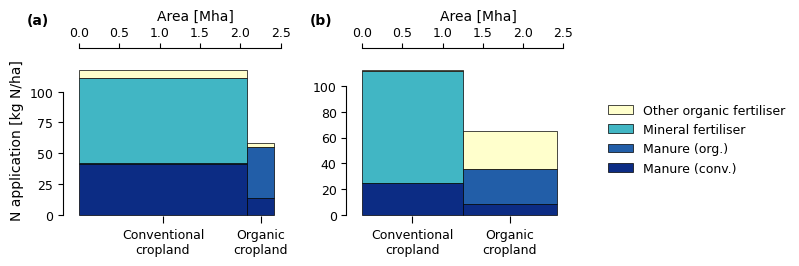

In [13]:
from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(1,2, figsize=(6.7,2), gridspec_kw={'wspace' : 0.2})

i=0
for scn, year in [('Base20','2020'),('Sust50','2050')]:

    ax = axs[i]
    
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.2,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]' if i==0 else '',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )

    if i == 1:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    else:
        ax.legend().set_visible(False)

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    pstr = ', '.join((scn,year))
    print(pstr)
    print('-'*len(pstr))
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)
    i += 1

plt.tight_layout()
annotate_axs(axs, offset=(-2,2.5))
plt.savefig('figs/mp2025/Fig11.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/mp2025/Fig11.pdf', dpi=300, bbox_inches='tight')
plt.show()

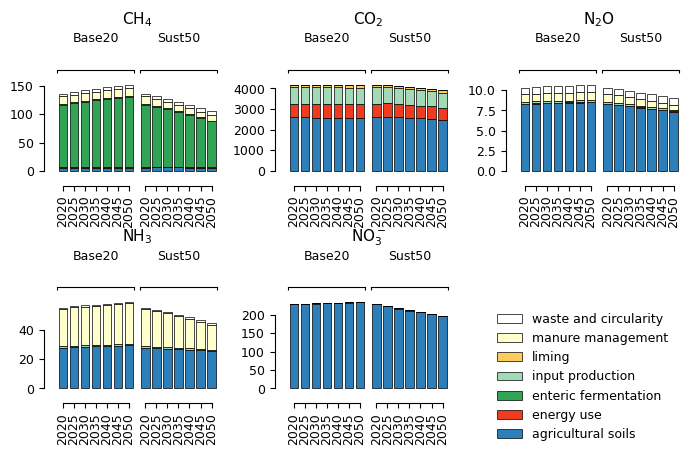

In [15]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NO3' : (62/14),
    'NOx' : 1,
    'NH4' : 1,
    'PO4' : 1,
    'K' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NO3' : 'NO$_3^-$',
    'NOx' : 'NO$_X$',
    'NH4' : 'NH$_4$',
    'PO4' : 'PO$_4^{3-}$',
    'K' : 'K'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','CO','N2','NOx','K','NH4','PO4','NMVOC','PM','SO2'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,4.5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **{k:v for k,v in bar_style.items() if k!='cmap'},
        cmap=cat7_cmap()
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig13.png', dpi=300)
plt.savefig('figs/mp2025/Fig13.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

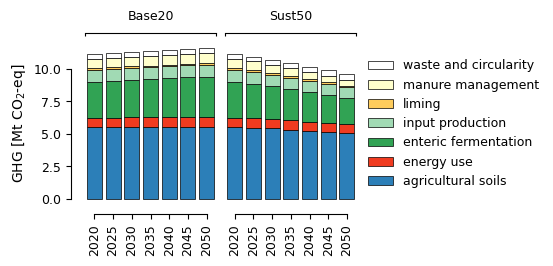

In [16]:
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
) / 1_000_000_000 # [Mt]
fig, ax = plt.subplots(1,1, figsize=(3.5,2))
cm.plot.bar(
    ghg,
    group_levels='scn',
    ax=ax,
    ylabel='GHG [Mt CO$_2$-eq]',
    **{k:v for k,v in bar_style.items() if k!='cmap'},
    cmap=cat7_cmap()
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
plt.show()

tab_data = ghg.sum(axis=1).to_frame()
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

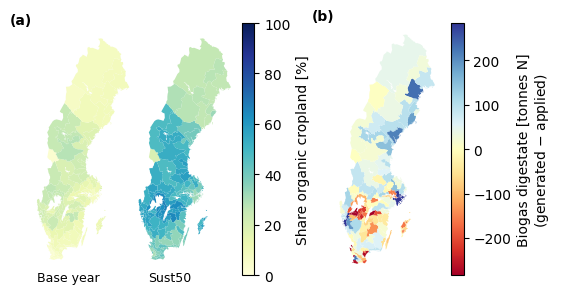

Share organic per region: 19-66%


In [17]:
plot_data1 = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,3, figsize=(5.5,3), gridspec_kw={'width_ratios' : [1,1.25, 2.2], 'wspace' : 0})

ax=axs[0]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Base year', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

ax=axs[1]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Sust50', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Share organic cropland [%]', fontsize=10)

plot_data2 = (session.get_attr('w','organic_fertiliser_N','region').loc[('Sust50','2050')] - session.get_attr('c','fertiliser.organic_N','region').loc[('Sust50','2050')]) / 1_000

ax=axs[2]
cm.plot.map_from_series(
    plot_data2,
    ax = ax,
    cmap = 'RdYlBu',
    vmax = plot_data2.abs().quantile(0.95),
    vmin = -plot_data2.abs().quantile(0.95),
    legend = False
)
ax.axis('off')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biogas digestate [tonnes N]\n(generated $\minus$ applied)', fontsize=10)

plt.tight_layout()
annotate_axs(axs[[0,2]], offset=(0,0))
plt.savefig('figs/mp2025/Fig14.png', bbox_inches='tight', dpi=300)
plt.savefig('figs/mp2025/Fig14.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"Share organic per region: {plot_data1.loc[('Sust50','2050')].min():.0f}-{plot_data1.loc[('Sust50','2050')].max():.0f}%")

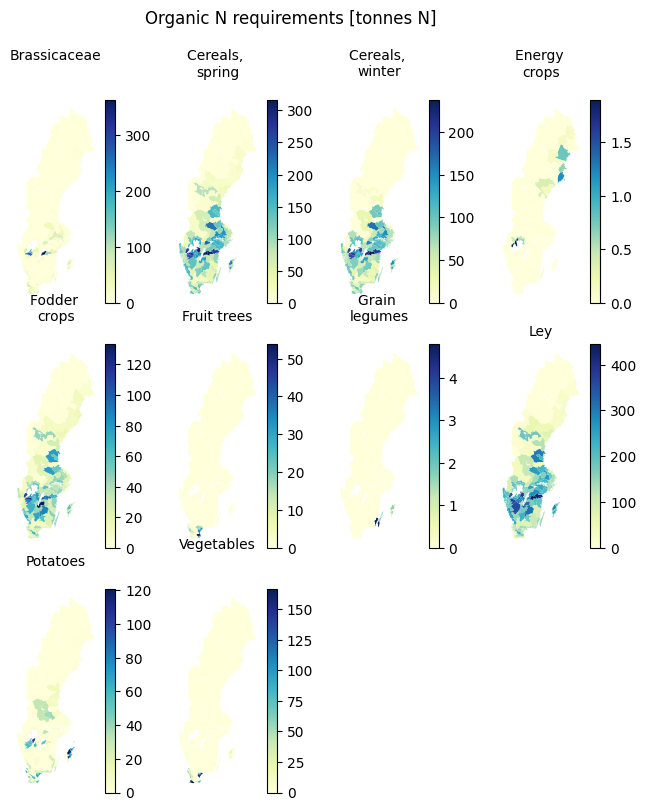

In [18]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Organic N requirements [tonnes N]')
plt.show()

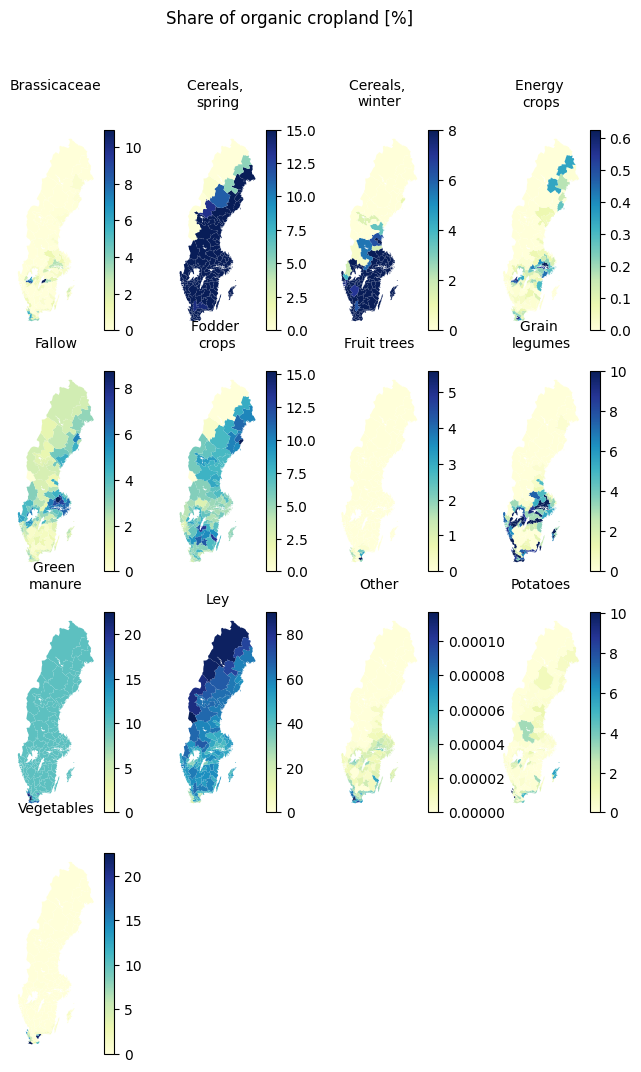

In [19]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

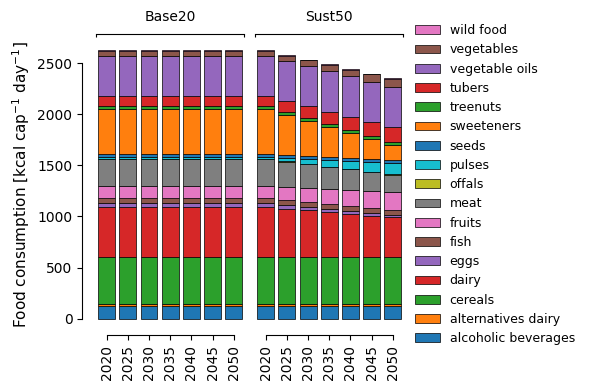

In [20]:
plot_data = (
    session.get_attr('d', 'nutrient_supply', ['nutrient','food_group'])
    .loc[:,'kcal']
    .div(
        session.get_attr('d','population')*1_000_000,
        axis=0
    )
    .div(365.25)
)

fig,ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    group_levels='scn',
    ylabel='Food consumption [kcal cap$^{-1}$ day$^{-1}$]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()

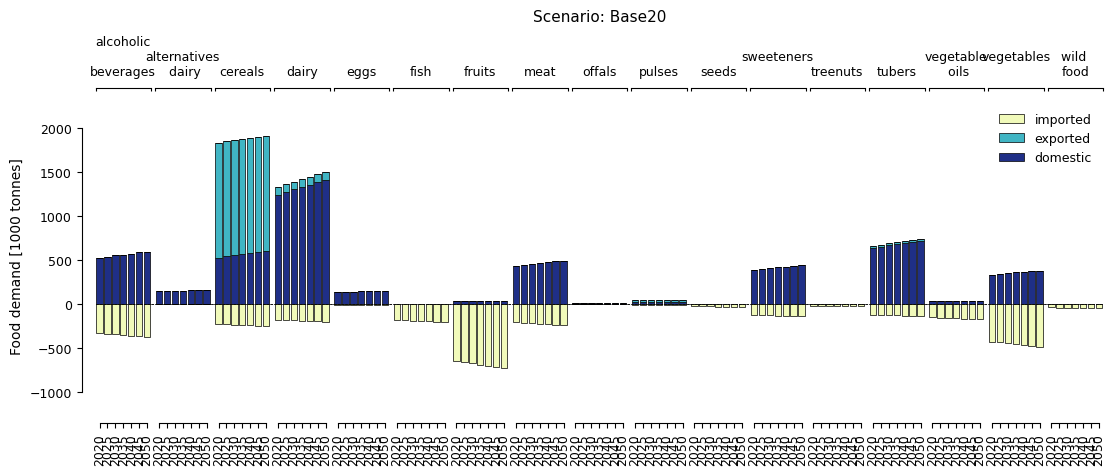

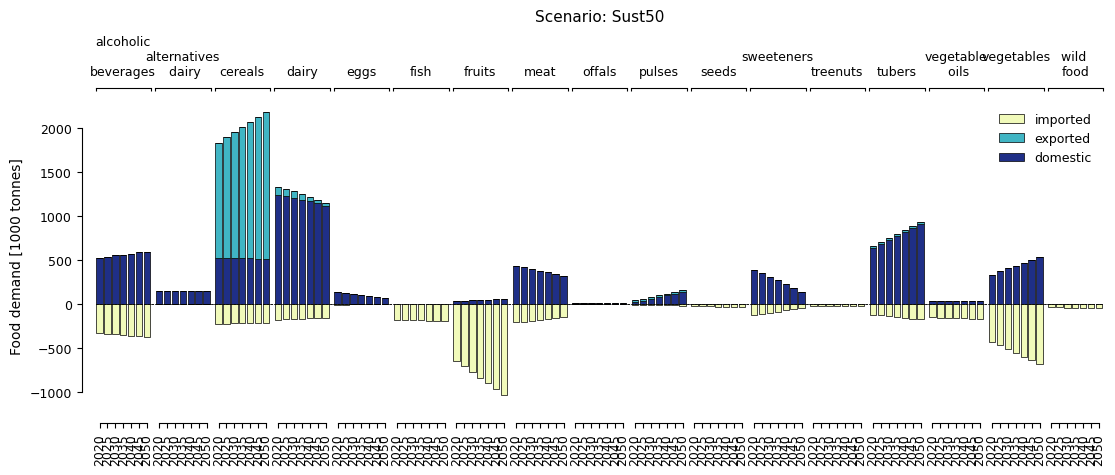

In [21]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax,
                ylim=(-1200, 2300), totmarker='none', ylabel='Food demand [1000 tonnes]', **bar_style)
    plt.show()

### Soil carbon

In [22]:
soil = cm.SoilC(
    par = cm.ParameterRetriever('SoilC'),
    session = session
)
soil.make_input()
soil.run_ICBM(extend=0)

[15:59:12][SoilC] Calculating re... 2.1s   
[15:59:12][SoilC] Getting crop residues C input and h-values... 14.7s   
[15:59:27][SoilC] Getting cover crop residues C input and h-values... 2.5s   
[15:59:30][SoilC] Getting manure C input and h-values... 21.6s   
[15:59:51][SoilC] Getting organic fertiliser C input and h-values... 0.5s   
[15:59:52][SoilC] Done! Elapsed time: 41 sec
[15:59:52][SoilC] Running ICBM... 0.3s   
[15:59:52][SoilC] Done! Elapsed time: 0 sec


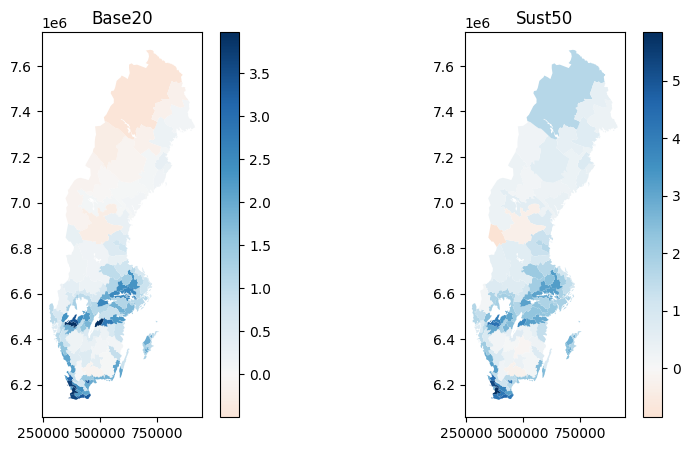

In [23]:
plot_data = soil.get_data(groupby='region') / 1000
plot_data = plot_data.xs('2050',level='year') - plot_data.xs('2020',level='year')
fig,axs = cm.plot.subplots(
    plot_data,
    index='scn',
    plot_fn=cm.plot.map_from_series,
    cmap_zero_midpoint = 'shrink',
    cmap = 'RdBu'
)

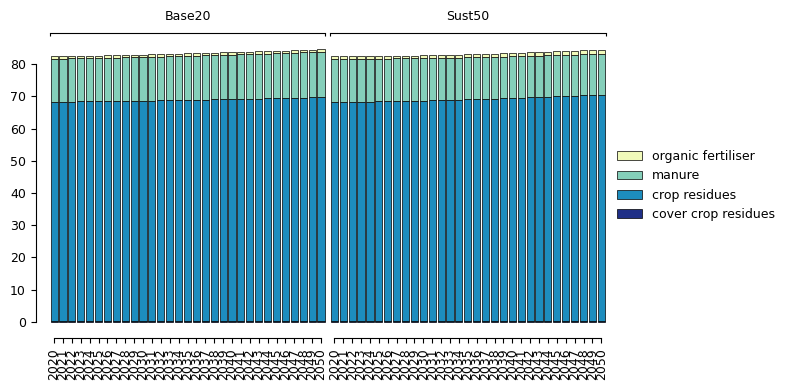

In [24]:
plot_data = soil.get_data(pool='C', groupby='input') / 1_000 # tonnes C per ha
fig,ax = plt.subplots(figsize=(8,4))
cm.plot.bar(
    plot_data,
    group_levels='scn',
    ax=ax,
    **bar_style
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()

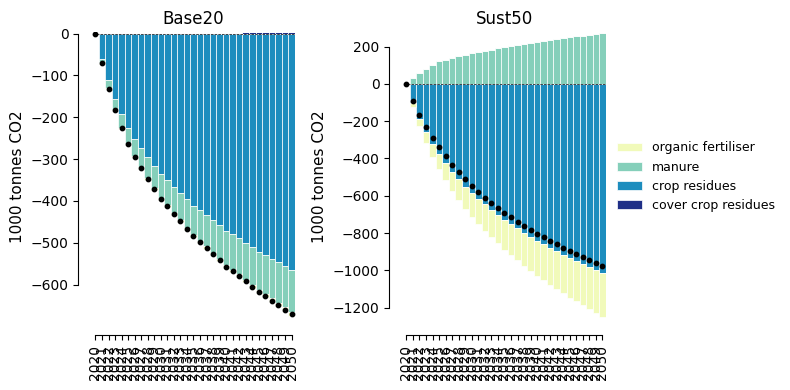

In [25]:
plot_data = soil.get_flux(groupby='input') / 1_000_000 # 1000 tonnes CO2
fig, axs = cm.plot.subplots(
    plot_data,
    index='scn',
    plot_fn=cm.plot.bar,
    size=(4,4),
    cmap='YlGnBu',
    bar_width=1,
    edgecolor='white',
    ylabel='1000 tonnes CO2'
)
axs[0].get_legend().remove()
axs[-1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()